![](imagens/cabecalho_ILUM.png)

# Projeto Final de PCD — Contagem e Comparação de Open Reading Frames (ORFs) por Comprimento e GC%

**Nome:** Giovanni de Almeida Moreira (2610060)     
**Instituição:** Ilum, Escola de Ciência    

Esse projeto tem como objetivo encontrar quais são as Open Reading Frames (ORFs) presentes sequências de DNA ou RNA, assim como sua quantidade de aminoácidos (aa) e seu percentual de nucleotídeos citosina e guanina (GC%), já que esses fatores revelam algumas características sobre elas. Ao final, compará-las através de gráficos de barra. <br>

Para fins de teste, o repositório inclui 6 sequências de organismos distintos disponíveis na pasta "sequencias", que estão detalhadas na tabela presente na seção de carregamento. O código porém, não se limita a esses exemplos, aceita qualquer arquivo FASTA (.fna) fornecido pelo usuário, desde que ele esteja salvo na pasta anteriormente mencionada.

In [10]:
# Importação das bibliotecas
import matplotlib.pyplot as plt
from Bio import SeqIO

## 1. Carregamento das Sequências de DNA/ e ou RNA

A tabela abaixo lista as sequências de teste disponivéis na pasta "sequencias", junto de seus repectivos organismos de origem:

|Nome do Arquivo|Origem|
|:---------------:|:--------:|
|teste_DNA1.fna|*Pseudomonas putida*|
|teste_DNA2.fna|*Pseudomonas aeruginosa PAO1*|
|teste_RNA3.fna|*HIV-1 M_97CD.KTB119*|
|teste_DNA4.fna|*Acanthamoeba polyphaga mimivirus*|
|teste_DNA5.fna|*Escherichia coli O157:H7*|
|teste_DNA6.fna|*Escherichia coli str. K-12*|

Ao executar a célula abaixo, o código irá pedir o nome de dois aquivos. Os nomes devem ser digitados exatamente como aparecem na tabela (incluindo a extensão `.fna`). Também é possível utilizar outros arquivos no formato FASTA, desde que eles estejam salvos na pasta "sequencias".

Como arquivos em formato FASTA costumam conter várias sequências - como em bactérias que, além do genoma, tem a sequência do plasmídeo - o código seleciona o registro de maior comprimento de cada arquivo, assumindo que ele seja o genoma. 

In [52]:
# Input que possibilita a escolha dos arquivos .fna desejados
arquivo_1 = input("Qual é o nome do arquivo onde está seu 1º genoma de interesse?")
arquivo_2 = input("Qual é o nome do arquivo onde está seu 2º genoma de interesse?")

caminho_1 = f"sequencias_teste/{arquivo_1}"
caminho_2 = f"sequencias_teste/{arquivo_2}"

registro_1 = list(SeqIO.parse(caminho_1, "fasta"))
registro_2 = list(SeqIO.parse(caminho_2, "fasta"))

genoma_1 = str(max(registro_1, key=lambda x: len(x.seq)).seq)
genoma_2 = str(max(registro_2, key=lambda x: len(x.seq)).seq)

## 2. Identificação das ORFs

In [45]:
def encontrar_orfs(sequencia):
    """Encontra as ORFs contidas em uma sequencia de DNA ou RNA.
    
    Args:
        str: String representando uma sequência de DNA
        
    Returns: 
        dict: Dicionário cujas chaves seguem o formato
            "ORF_n" (onde n é um número inteiro identificando a ORF)
            e cujos valores são strings com a sequência de aminoácidos
            de cada ORF.
    """
    
    # Garante que a entrada seja do tipo string
    assert isinstance(sequencia, str), \
        "O argumento de entrada deve ser uma string!"

    # Tira quebras de linha
    sequencia = sequencia.replace("\n", "")

    # Transcreve a sequência de entrada
    sequencia = sequencia.replace("T", "U")

    # Cria um dicionário vazio para a adição de ORFs
    orfs = dict()
    contador = 1
    i = 0

    # Define quais são as terminações que uma ORF deve ter
    START = ["AUG"]
    STOP = ["UAA", "UAG", "UGA"]

    # Percorre toda a sequência, de 3 em 3, em busca de um códon "AUG"
    while i < len(sequencia) - 2:
        if sequencia[i:i+3] in START:
            achou_stop = False

            # Percorre a sequência buscando códons de parada
            for j in range(i, len(sequencia)-2, 3):
                codon = sequencia[j:j+3]
                if codon in STOP:

                    # Armazena o trecho entre o códon inicio e o códon parada
                    orf = sequencia[i:j+3]

                    # Armazena os ORFs dentro de um dicionário
                    orfs[f"ORF_{contador}"] = orf
                    contador += 1
                    i = j + 3
                    achou_stop = True
                    break
                
                # Previne loops infinitos
                if not achou_stop:
                        i += 1
        else:
                i += 1

    return orfs

## 3. Cálculos de Métrica das ORFs

Tendo as ORFs identificadas, é possível calcular algumas métricas que revelam aspectos importantes sobre elas. O comprimento de uma ORF, por exemplo, pode revelar sua provável função e também, distinguir se ela é um gene ou uma ORF espúria (que não é um gene real), já que ORFs que tem menos do que 100 aminoácidos tem maior chance de surgir por acaso, apesar da existência de sORFs reais. Já o contéudo GC pode revelar a assinatura genômica do organismo e sinais de transferência horizontal, além de influenciar a distribuição esperada de comprimentos de ORFs espúrias.

A função `conteudo_gc()`, como o nome diz, calcula o conteúdo GC presente em uma sequência de DNA ou RNA. Já as funções `contar_orfs_por_faixa_comprimento()` e `contar_orfs_por_faixa_gc()` classificam as ORFs encontradas em intervalos de comprimento (aminoácidos) e contéudo GC (%), respectivamente, contando quantas ORFs se encaixam em cada intervalo.

A escolha de agrupar as ORFs por faixa, ao invés de analisar cada ORF individualmente, veio da necessidade de melhor representá-las nas figuras da função `comparar_orfs()`, presente na seção 4, já que seria inviável representar números muito grandes de ORFs - que é o caso na maior parte dos genomas - em formato de gráficos de barras.

In [4]:
def conteudo_gc(sequencia):
    """Calcula a porcentagem de guanina (G) e citosina (C) em determinada sequência
    Args:
        sequencia (str): String contendo uma sequência de nucleotídeos.
        
    Returns:
        float: Conteúdo de G e C na sequência em forma de porcentagem, 
            arredondado a 1 casa decimal.
    """
    
    # Encontra o comprimento total da sequência
    comprimento_total = len(sequencia)

    # Encontra o número de nucleotídeos G + C
    gc = sequencia.count("G") + sequencia.count("C")

    # Calcula o GC%
    porcentagem = (gc * 100) / comprimento_total

    return round(porcentagem, 1)


In [25]:
def contar_orfs_por_faixa_comprimento(dict_orfs):

    """Conta quantas ORFs se encaixam em cada faixa de comprimento de aminoácidos.

    Args:
        dict_orfs (dict): Dicionário cujas chaves seguem o formato
            "ORF_n" (onde n é um número inteiro identificando a ORF)
            e cujos valores são strings com a sequência de aminoácidos
            de cada ORF. Formato retornado por `encontrar_orfs()`.

    Returns:
        dict: Dicionário que tem como chaves intervalos de tamanhos e
            como valores a quantidade de ORFs que se encaixam nos
            respectivos tamanhos.
    """

    # Cria dicionário com faixas de comprimento de aminoácidos
    dict_comprimentos = {
        "0 à 100":0, 
        "101 à 250":0, 
        "251 à 500":0, 
        "501 à 750":0, 
        "Maior que 750":0
    }
    
    for orf, gene in dict_orfs.items():
        # Calcula o comprimento de cada ORF
        comprimento_orf = (len(gene)-3)/3

        # Classifica cada ORF de acordo com seu comprimento
        if comprimento_orf <= 100:
            dict_comprimentos["0 à 100"] += 1

        if comprimento_orf > 100 and comprimento_orf <= 250:
            dict_comprimentos["101 à 250"] += 1

        if comprimento_orf > 250 and comprimento_orf <= 500:
            dict_comprimentos["251 à 500"] += 1

        if comprimento_orf > 500 and comprimento_orf <= 750:
            dict_comprimentos["501 à 750"] += 1

        if comprimento_orf > 750:
            dict_comprimentos["Maior que 750"] += 1

    return dict_comprimentos

In [5]:
def contar_orfs_por_faixa_gc(dict_orfs):
    """Conta quantas ORFs se encaixam em cada faixa de conteudo GC.
    Args:
        dict_orfs (dict): Dicionário cujas chaves seguem o formato
            "ORF_n" (onde n é um número inteiro identificando a ORF)
            e cujos valores são strings com a sequência de nucleotídeos
            de cada ORF. Formato retornado por `encontrar_orfs()`.
    
    Returns:
        dict: Dicionário que tem como chaves intervalos de GC% e
            como valores a quantidade de ORFs que se encaixam nas
            respectivas porcentagens.
    """

    # Cria dicionário com faixas de GC%
    grafo_GC = {
        "0 à 10%": 0,
        "10 à 20%": 0,
        "20 à 30%": 0,
        "30 à 40%": 0,
        "40 à 50%": 0,
        "50 à 60%": 0,
        "60 à 70%": 0,
        "70 à 80%": 0,
        "80 à 90%": 0,
        "90 à 100%": 0
    }

    # Classifica cada ORF de acordo com seu GC%
    for ORF, gene in dict_orfs.items():
        GC = conteudo_gc(gene)

        if GC < 10:
            grafo_GC["0 à 10%"] += 1
        elif GC < 20:
            grafo_GC["10 à 20%"] += 1
        elif GC < 30:
            grafo_GC["20 à 30%"] += 1
        elif GC < 40:
            grafo_GC["30 à 40%"] += 1
        elif GC < 50:
            grafo_GC["40 à 50%"] += 1
        elif GC < 60:
            grafo_GC["50 à 60%"] += 1
        elif GC < 70:
            grafo_GC["60 à 70%"] += 1
        elif GC < 80:
            grafo_GC["70 à 80%"] += 1
        elif GC < 90:
            grafo_GC["80 à 90%"] += 1
        else:
            grafo_GC["90 à 100%"] += 1

    return grafo_GC

## 4. Comparação Entre as Sequências

A função a seguir **`compara_orfs()`** utiliza todas as funções descritas anteriormente para a criação de gráficos de barra a fim de comparar os dois genomas escolhidos no início do notebook. O código gera 3 figuras: "Número de ORFs por Sequência", "Distribuição de Comprimento das ORFs (aa)" e "Distribuição do Conteúdo GC das ORFs", respectivamente.

Ao executar a célula abaixo, o código irá perguntar o nome que você deseja dar para cada genoma que está sendo analisado. Note que as respostas correspondem aos nomes que serão escritos nos gráficos posteriormente.

In [26]:
def comparar_orfs(sequencia_1, sequencia_2):

    """Cria 3 gráficos que comparam quantidade, comprimento e o conteúdo 
    GC% de ORFs contidas nas sequências de entrada.
    Args:
        sequencia_1 (str): String contendo uma sequência de DNA ou RNA.
        sequencia_2 (str): String contendo uma sequência de DNA ou RNA.

    Returns:
        None: A função não retorna nenhum valor; ela exibe os três
        gráficos diretamente na tela.
    """

    # Transcreve as sequencias de DNA em RNA
    nome_sequencia1 = input("Qual nome você deseja dar a sequência 1?")
    nome_sequencia2 = input("Qual nome você deseja dar a sequência 2?")

    # Encontra os ORFs que cada sequência possui
    dict_orfs1 = encontrar_orfs(sequencia_1)
    dict_orfs2 = encontrar_orfs(sequencia_2)

    # Define os subplots pra figura 1: Número de ORFs por Sequência
    fig1, x1 = plt.subplots()

    ## Cria duas listas que são o x e o y do gráfico, sequencias e numero_de_orfs, respectivamente
    sequencias = [nome_sequencia1, nome_sequencia2]
    numero_de_orfs = [len(dict_orfs1), len(dict_orfs2)]
    
    ## Plota o gráfico da fig. 1
    x1.bar(
        sequencias, 
        numero_de_orfs,
        color=("#4059AD", "#F4B942"),
        hatch=(".", "\\\\")
    )

    ## Adiciona título, legendas e grid horizontal
    x1.set_title("Número de ORFs por Sequência")

    x1.bar_label(x1.containers[0])
    x1.set_ylabel("Número de ORFs")
    x1.grid(axis="y", alpha=0.3)

    x1.set_axisbelow(True)
    
    # Define os subplots e título para figura 2: Distribuição do Comprimento das ORFs(aa)
    fig2, (x2_1, x2_2) = plt.subplots(
        1, 
        2, 
        figsize=(15, 6), 
        sharey=True,
    )
    fig2.suptitle("Distribuição do Comprimento das ORFs(aa)", fontsize=18)

    ## Cria dois dicionários que contém as ORFs classificadas por comprimento
    comprimento_orfs1 = contar_orfs_por_faixa_comprimento(dict_orfs1)
    comprimento_orfs2 = contar_orfs_por_faixa_comprimento(dict_orfs2)

    ## Plota o gráfico (A) da fig 2.
    x2_1.bar(
        comprimento_orfs1.keys(), 
        comprimento_orfs1.values(), 
        color="#4059AD", 
        hatch=".",
        label=f"Número Total de ORFs: {numero_de_orfs[0]}"
    )

    ### Adiciona título, legendas e grid horizontal
    x2_1.set_title(f"(A) {nome_sequencia1}")

    x2_1.set_ylabel("Número de ORFs")
    x2_1.set_xlabel("Comprimento (aa)")
    x2_1_labels = [
        f"{valor} ({100 * valor / numero_de_orfs[0]:.0f}%)"
        for valor in comprimento_orfs1.values()
    ]
    x2_1.bar_label(x2_1.containers[0], labels=x2_1_labels, fontsize="small")
    x2_1.legend()

    x2_1.grid(axis="y", alpha=0.3)
    x2_1.set_axisbelow(True)

    ## Plota o gráfico (B) da fig.2
    x2_2.bar(
        comprimento_orfs2.keys(), 
        comprimento_orfs2.values(), 
        color="#F4B942", 
        hatch="\\\\",
        label=f"Número Total de ORFs: {numero_de_orfs[1]}"
    )
    ### Adiciona título, legendas e grid horizontal
    x2_2.set_title(f"(B) {nome_sequencia2}")

    x2_2_labels = [
        f"{valor} ({100 * valor / numero_de_orfs[1]:.0f}%)"
        for valor in comprimento_orfs2.values()
    ]
    x2_2.bar_label(x2_2.containers[0], labels=x2_2_labels, fontsize="small")
    x2_2.set_xlabel("Comprimento (aa)") 

    x2_2.grid(axis="y", alpha=0.3)
    x2_2.set_axisbelow(True)
    x2_2.legend()
    
    ## Adequa o tamanho da fig. 2
    fig2.tight_layout()

    # Define os subplots e título para figura 3: Distribuição do Conteúdo GC das ORFs
    fig3, (x3_1, x3_2) = plt.subplots(
        1, 
        2, 
        figsize=(15, 6), 
        sharey=True,
    )
    fig3.suptitle("Distribuição do Conteúdo GC das ORFs", fontsize=18)
    
    ## Cria variáveis que armazenam o GC% global de suas respectivas sequências 
    gc_sequencia1 = conteudo_gc(sequencia_1)
    gc_sequencia2 = conteudo_gc(sequencia_2)

    ## Cria dois dicionário que contém as ORFs classficadas por GC%
    gc_dict_orfs1 = contar_orfs_por_faixa_gc(dict_orfs1)
    gc_dict_orfs2 = contar_orfs_por_faixa_gc(dict_orfs2)

    ## Plota o gráfico (A) da fig. 3
    x3_1.bar(
        gc_dict_orfs1.keys(), 
        gc_dict_orfs1.values(), 
        color="#4059AD", 
        hatch=".", 
        label=f"GC global: {gc_sequencia1}%"
    )

    ### Adiciona título, legendas e grid horizontal
    x3_1.set_title(f"(A) {nome_sequencia1}")

    x3_1_labels = [
        f"{valor} ({100 * valor / numero_de_orfs[0]:.0f}%)"
        for valor in gc_dict_orfs1.values()
    ]
    x3_1.bar_label(x3_1.containers[0], labels=x3_1_labels, fontsize="small")
    x3_1.tick_params(axis="x", rotation=30)
    
    x3_1.set_ylabel("Número de ORFs")
    x3_1.set_xlabel("Conteúdo GC(%)")
    x3_1.legend()

    x3_1.grid(axis="y", alpha=0.3)
    x3_1.set_axisbelow(True)
    
    ## Plota o gráfico (B) da fig. 3
    x3_2.bar(
        gc_dict_orfs2.keys(), 
        gc_dict_orfs2.values(), 
        color="#F4B942", 
        hatch="\\\\",
        label=f"GC global: {gc_sequencia2}%"
    )

    ### Adiciona título, legendas e grid horizontal
    x3_2.set_title(f"(B) {nome_sequencia2}")

    x3_2_labels = [
        f"{valor} ({100 * valor / numero_de_orfs[1]:.0f}%)"
        for valor in gc_dict_orfs2.values()
    ]
    x3_2.bar_label(x3_2.containers[0], labels=x3_2_labels, fontsize="small")
    x3_2.tick_params(axis="x", rotation=30)
    x3_2.set_xlabel("Conteúdo GC(%)")
    x3_2.legend()

    x3_2.grid(axis="y", alpha=0.3)
    x3_2.set_axisbelow(True)
    
    ## Adequa o tamanho da figura
    fig3.tight_layout()
    
    return plt.show()

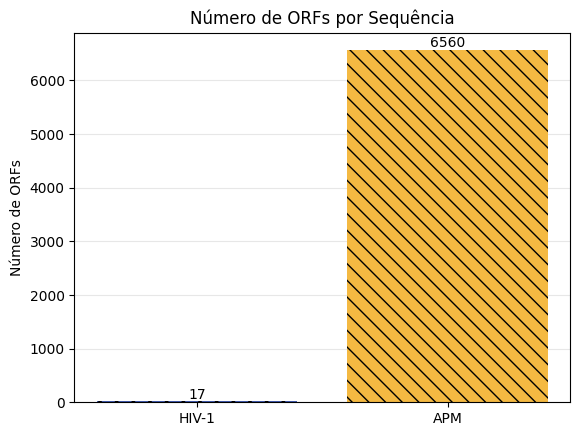

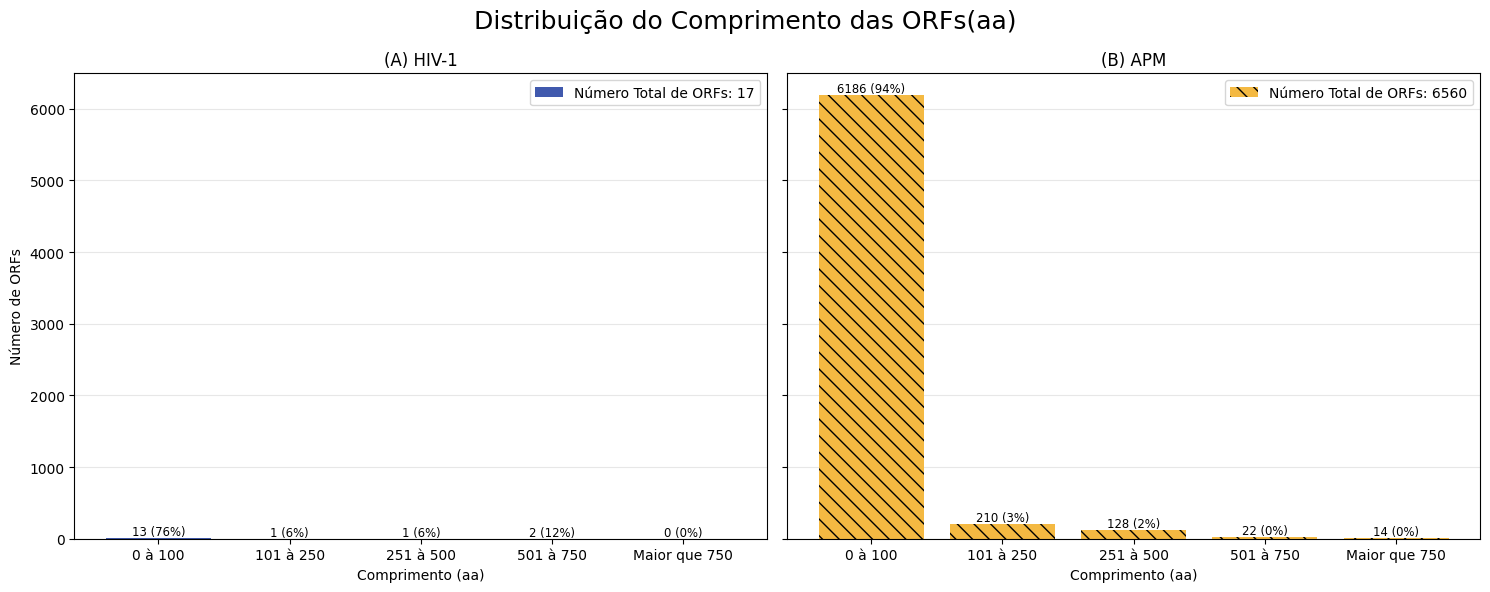

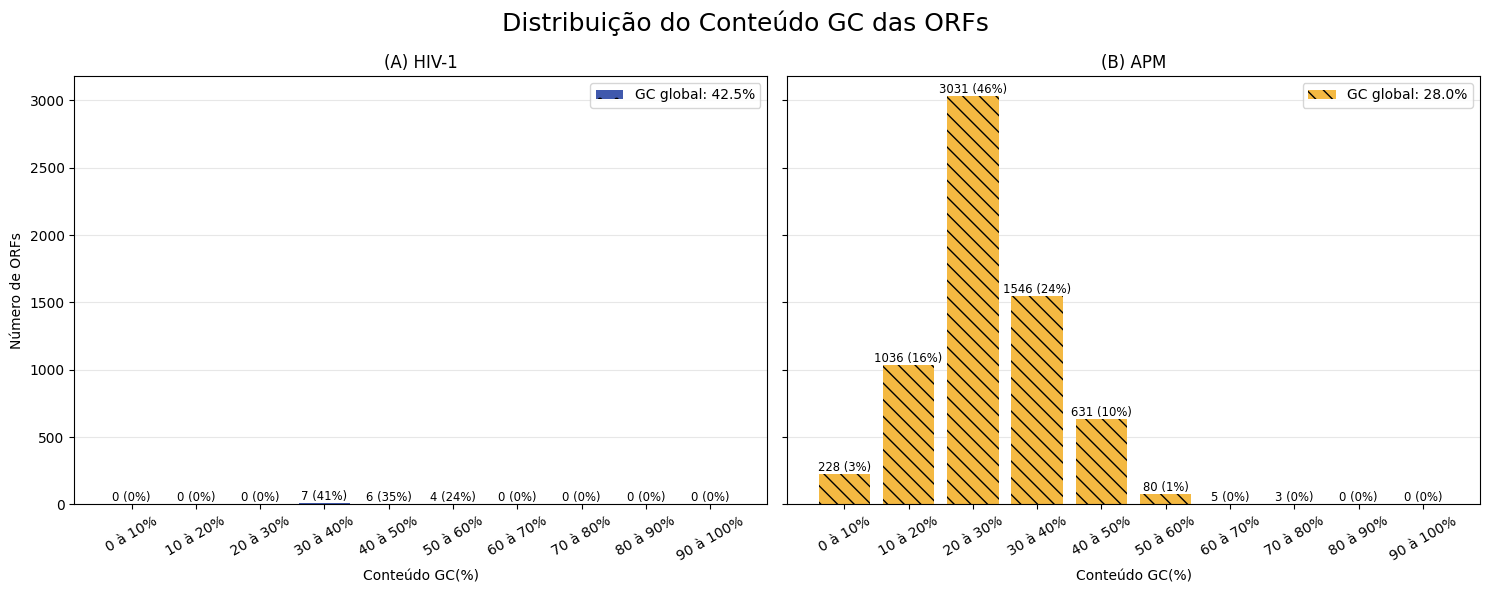

In [53]:
comparar_orfs(genoma_1, genoma_2)

## 5. Conclusão

Insira conclusão

## Referências

Insira referências

![](imagens\rodape_ILUM.png)